### Import Library

In [1]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Data Understanding

In [2]:
df = pd.read_csv("/content/UpdatedResumeDataSet.csv")
df.head(10)

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
5,Data Science,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...
9,Data Science,Expertise â Data and Quantitative Analysis â...


In [3]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 962
Jumlah kolom: 2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [5]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 796


In [6]:
display(df.isnull().sum().to_frame("Jumlah Missing Value"))

,Jumlah Missing Value
Category,0
Resume,0


In [7]:
print("Jumlah kategori:", df["Category"].nunique())

Jumlah kategori: 25


In [8]:
df["Category"].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


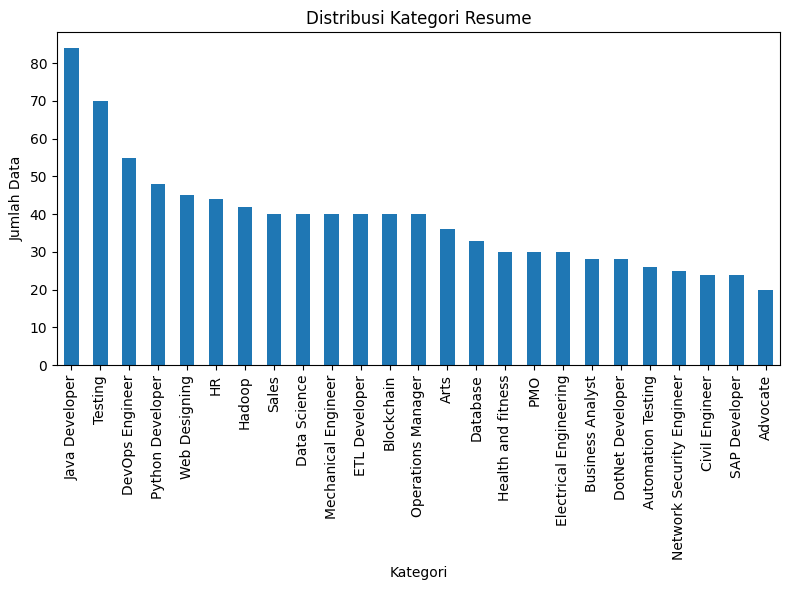

In [9]:
# VISUALISASI DISTRIBUSI KATEGORI
category_counts = df["Category"].value_counts()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)

category_counts.plot(kind="bar")
plt.title("Distribusi Kategori Resume")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

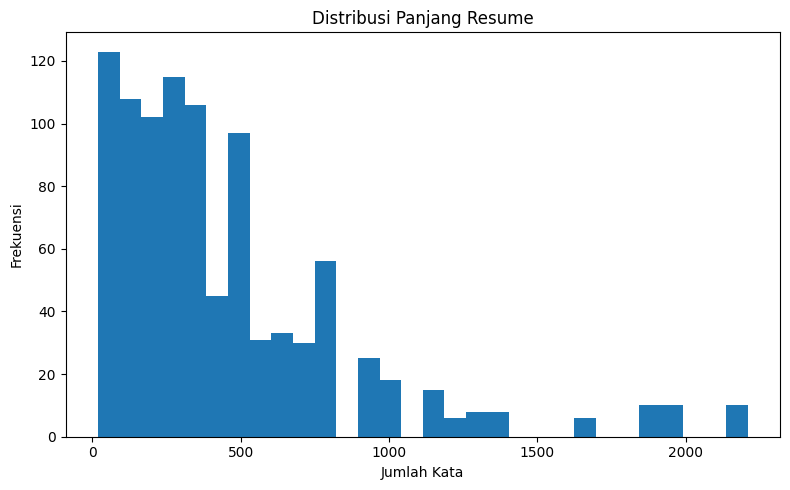

,Statistik Panjang Resume
count,962.000000
mean,450.497921
std,415.868459
min,19.000000
25%,166.000000
50%,329.000000
75%,589.250000
max,2209.000000


In [10]:
# ANALISIS PANJANG RESUME

df["resume_word_count"] = df["Resume"].astype(str).apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(8, 5))
plt.hist(df["resume_word_count"], bins=30)
plt.title("Distribusi Panjang Resume")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

display(
    df["resume_word_count"]
    .describe()
    .to_frame("Statistik Panjang Resume")
)


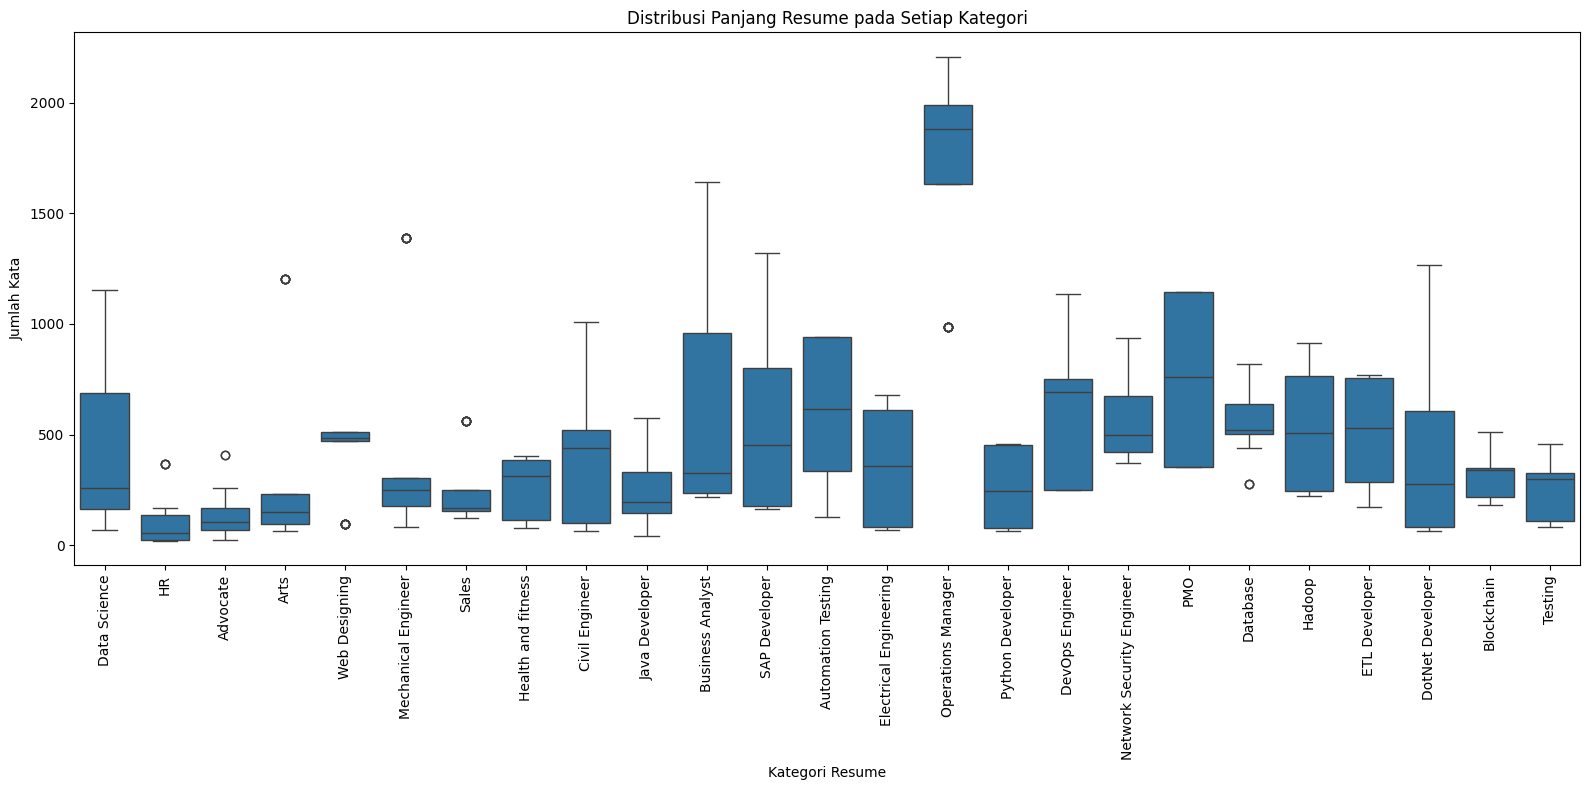

In [11]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df,
    x="Category",
    y="resume_word_count"
)

plt.xticks(rotation=90)
plt.xlabel("Kategori Resume")
plt.ylabel("Jumlah Kata")
plt.title("Distribusi Panjang Resume pada Setiap Kategori")

plt.tight_layout()
plt.show()

### Data Preparation

In [12]:
# TEXT PREPROCESSING

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    text = re.sub(r"[^a-zA-Z0-9+#\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [13]:
# TERAPKAN PREPROCESSING

df["clean_resume"] = df["Resume"].apply(clean_text)

display(
    df[["Category", "clean_resume"]].head()
)

,Category,clean_resume
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may 2013 to may 2017 b e uit...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


In [14]:
# FEATURE EXTRACTION MENGGUNAKAN SENTENCE-BERT

sbert_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

X = sbert_model.encode(
    df["clean_resume"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

X = np.array(X)

print("Shape embedding:", X.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Shape embedding: (962, 384)


In [15]:
# Label encoding

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["Category"]
)

print("Daftar kelas:")

for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=>", label)

Daftar kelas:
0 => Advocate
1 => Arts
2 => Automation Testing
3 => Blockchain
4 => Business Analyst
5 => Civil Engineer
6 => Data Science
7 => Database
8 => DevOps Engineer
9 => DotNet Developer
10 => ETL Developer
11 => Electrical Engineering
12 => HR
13 => Hadoop
14 => Health and fitness
15 => Java Developer
16 => Mechanical Engineer
17 => Network Security Engineer
18 => Operations Manager
19 => PMO
20 => Python Developer
21 => SAP Developer
22 => Sales
23 => Testing
24 => Web Designing


In [16]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (769, 384)
Data test : (193, 384)


### Modeling

In [17]:
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Model Linear SVM berhasil dilatih.")

Model Linear SVM berhasil dilatih.


### Evaluation

In [18]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("===== FINAL EVALUATION: LINEAR SVM =====")
print("Accuracy        :", round(accuracy, 4))
print("Precision Macro :", round(precision_macro, 4))
print("Recall Macro    :", round(recall_macro, 4))
print("F1 Macro        :", round(f1_macro, 4))
print("F1 Weighted     :", round(f1_weighted, 4))

===== FINAL EVALUATION: LINEAR SVM =====
Accuracy        : 0.9948
Precision Macro : 0.9943
Recall Macro    : 0.9964
F1 Macro        : 0.995
F1 Weighted     : 0.9949


In [19]:
report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(report_df)

,precision,recall,f1-score,support
Advocate,1.000000,1.000000,1.000000,4.000000
Arts,1.000000,1.000000,1.000000,7.000000
Automation Testing,1.000000,1.000000,1.000000,5.000000
Blockchain,1.000000,1.000000,1.000000,8.000000
Business Analyst,0.857143,1.000000,0.923077,6.000000
Civil Engineer,1.000000,1.000000,1.000000,5.000000
Data Science,1.000000,1.000000,1.000000,8.000000
Database,1.000000,1.000000,1.000000,7.000000
DevOps Engineer,1.000000,0.909091,0.952381,11.000000
DotNet Developer,1.000000,1.000000,1.000000,5.000000


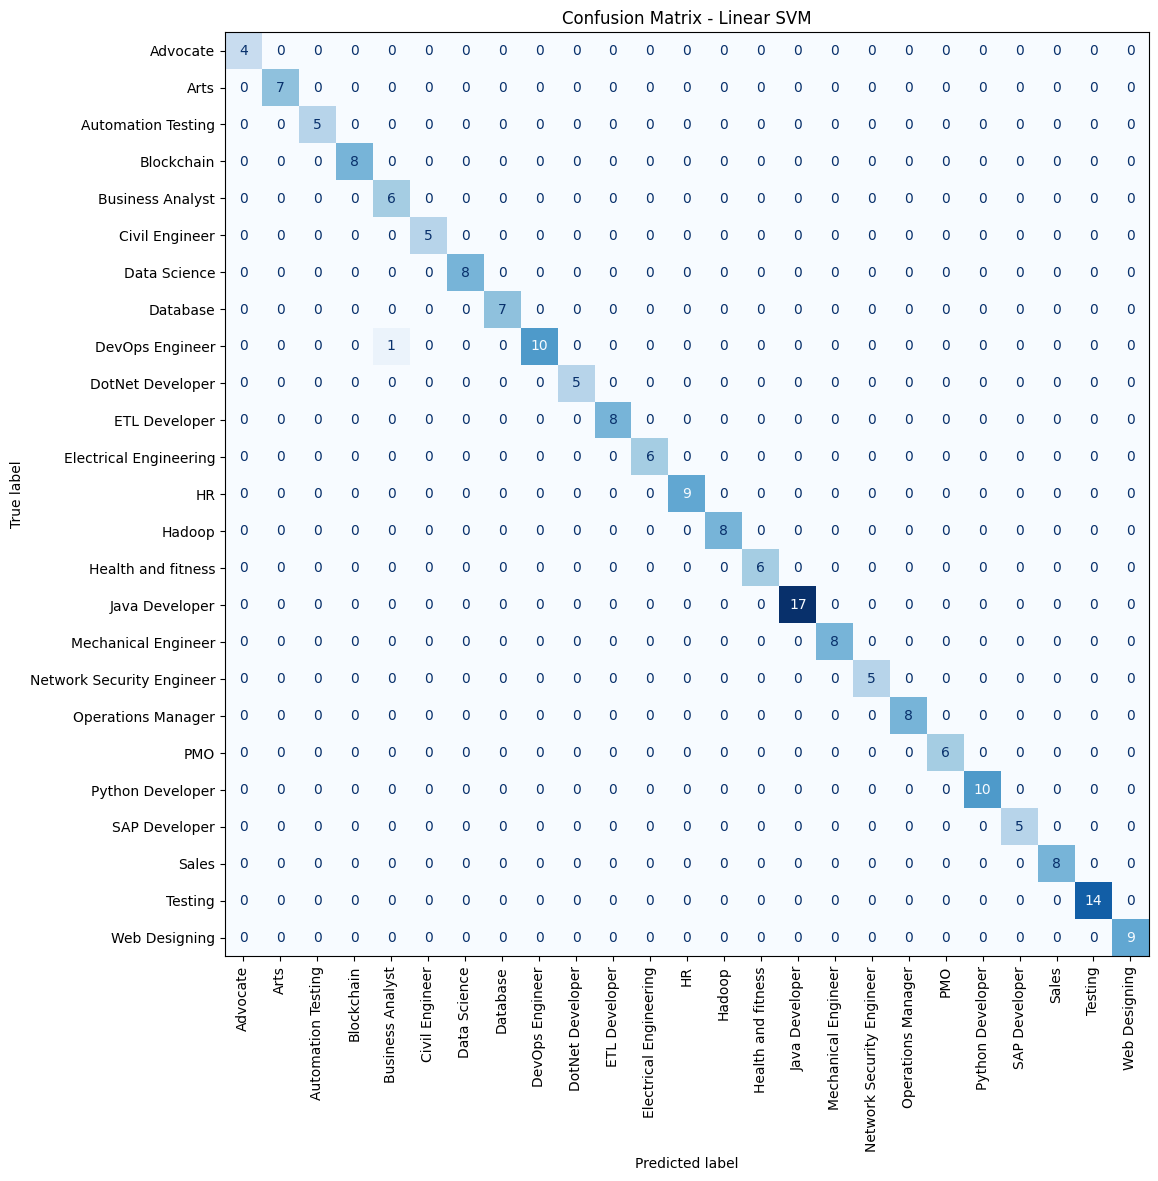

In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    xticks_rotation=90
)

plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("F1 Macro tiap fold:", cv_scores)
print("Rata-rata F1 Macro:", round(cv_scores.mean(), 4))
print("Standar deviasi:", round(cv_scores.std(), 4))

F1 Macro tiap fold: [0.98755556 0.98555556 1.         0.99501832 0.99025837]
Rata-rata F1 Macro: 0.9917
Standar deviasi: 0.0052


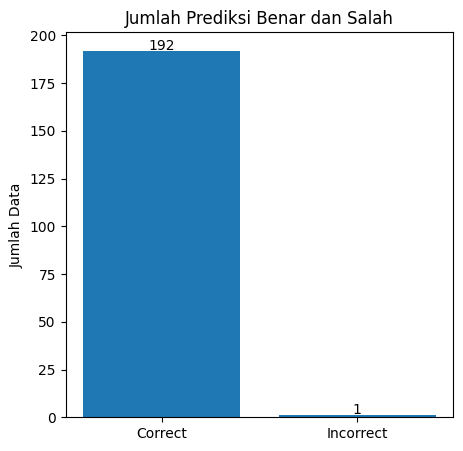

In [22]:
status = pd.Series(
    np.where(y_test == y_pred, "Correct", "Incorrect")
).value_counts()

plt.figure(figsize=(5,5))
plt.bar(status.index, status.values)

plt.title("Jumlah Prediksi Benar dan Salah")
plt.ylabel("Jumlah Data")

for i, v in enumerate(status.values):
    plt.text(i, v+0.5, str(v), ha="center")

plt.show()

In [23]:
# Simpan model

os.makedirs("model_artifacts", exist_ok=True)

joblib.dump(
    svm_model,
    "model_artifacts/resume_classifier_model.pkl"
)

joblib.dump(
    label_encoder,
    "model_artifacts/label_encoder.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [24]:
# ZIP DAN DOWNLOAD

!zip -r model_artifacts.zip model_artifacts

files.download("model_artifacts.zip")

  adding: model_artifacts/ (stored 0%)
  adding: model_artifacts/resume_classifier_model.pkl (deflated 4%)
  adding: model_artifacts/label_encoder.pkl (deflated 38%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>